<a href="https://colab.research.google.com/github/guravharshvardhan/Deep-Learning/blob/main/Experiment_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize (convert to float for better precision)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

# Convolution + Pooling
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

# Fully Connected
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10,
                    batch_size=64,
                    validation_data=(x_test, y_test))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - accuracy: 0.4387 - loss: 1.5541 - val_accuracy: 0.5351 - val_loss: 1.2933
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.5830 - loss: 1.1836 - val_accuracy: 0.5952 - val_loss: 1.1503
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.6350 - loss: 1.0528 - val_accuracy: 0.6345 - val_loss: 1.0575
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.6627 - loss: 0.9781 - val_accuracy: 0.6555 - val_loss: 1.0025
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 47ms/step - accuracy: 0.6832 - loss: 0.9175 - val_accuracy: 0.6703 - val_loss: 0.9667
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.6995 - loss: 0.8652 - val_accuracy: 0.6711 - val_loss: 0.9683
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.7161 - loss: 0.8211 - val_accuracy: 0.6783 - val_loss: 0.9362
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.7301 - loss: 0.7794 - 

In [ ]:
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Accuracy:", round(acc*100, 2), "%")

Accuracy: 69.77 %


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


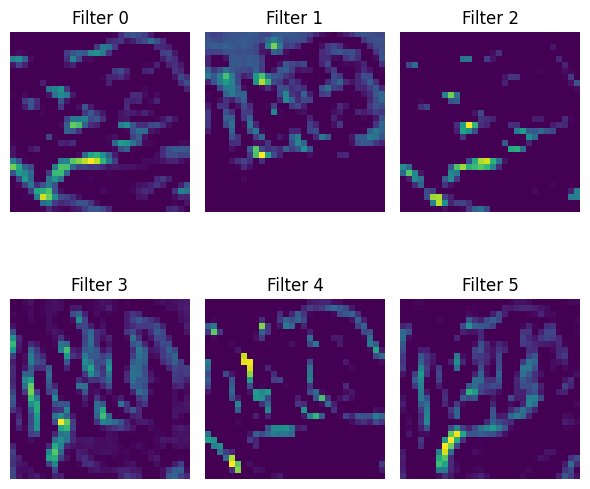

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

# Build model (IMPORTANT)
model(x_test[:1])

# Extract first convolution layer
layer_output = model.layers[0].output

# Create activation model
activation_model = Model(inputs=model.inputs, outputs=layer_output)

# Get feature maps
feature_maps = activation_model.predict(x_test[:1])

# FEATURE MAPS (clean + labeled)
plt.figure(figsize=(6,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(feature_maps[0][:,:,i], cmap='viridis')
    plt.title(f"Filter {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()

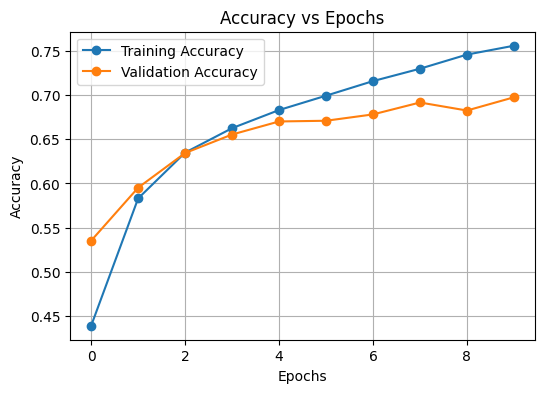

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')

plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Training Accuracy", "Validation Accuracy"])

plt.grid()
plt.show()

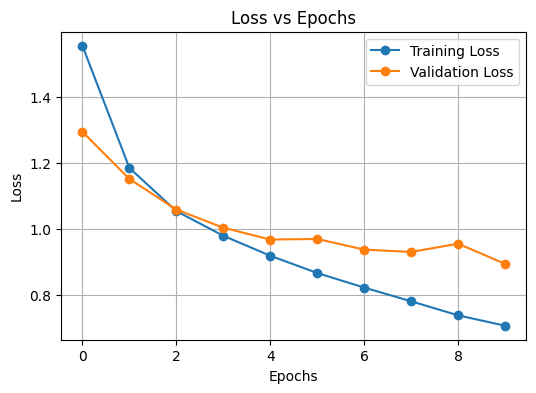

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], marker='o')
plt.plot(history.history['val_loss'], marker='o')

plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Training Loss", "Validation Loss"])

plt.grid()
plt.show()